In [131]:
import numpy as np 
from sklearn.datasets import fetch_20newsgroups
import json
import matplotlib.pyplot as plt
from collections import Counter

In [52]:
from cartm.preprocessing import (
    CorpusLoader,
    BatchedCorpusLoader,
    build_bow,
)

In [499]:
prefix = 'ntopics200decor_new_filtered_'

In [500]:
with open(prefix + 'phi_hist_vocab.json', 'r') as file:
    vocab = json.load(file)
    reverse_vocab = {value: key for key, value in vocab.items()}

print(f"{len(vocab)=}")

len(vocab)=30668


In [501]:
phi_hist = np.load(prefix + 'phi_hist.npy').T
print(f"{phi_hist.shape=}")

phi_hist.shape=(20, 30668, 50)


Text(0.5, 1.0, 'ntopics20decor_new_filtered_idea')

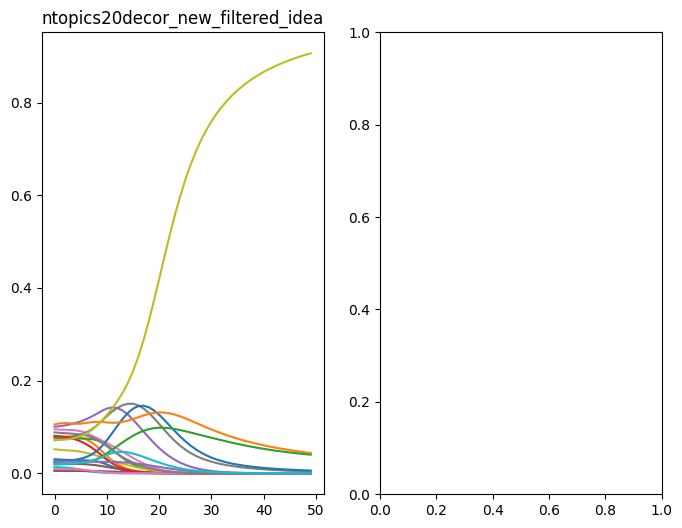

In [502]:
token = 'idea'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 6))

token_hist = [p for p in phi_hist[:, int(vocab[token]), :]]
for i in range(len(token_hist)):
    ax1.plot(token_hist[i])
ax1.set_title(prefix + token)


anchor_result.shape=(20, 5906)


Text(0.5, 1.0, 'Распределение якорных слов по темам')

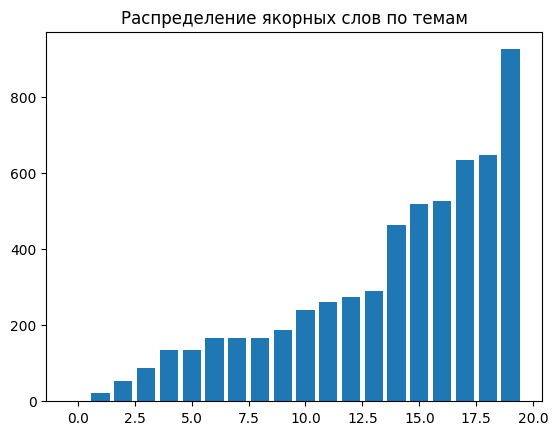

In [503]:
eps = 0
anchor_mask = (phi_hist[:, :, -1] >= 1 - eps).any(axis=0)  # True для столбцов (токенов), содержащих хотя бы одну 1
anchor_result = phi_hist[:, anchor_mask, -1]         # выборка токенов
print(f"{anchor_result.shape=}")

plt.bar(range(phi_hist.shape[0]), np.sort(np.sum(anchor_result, axis=1)))
plt.title("Распределение якорных слов по темам")

In [504]:
topic_anchors_mask = np.where(phi_hist[:, :, -1] >= 1 - eps)
print(f"{topic_anchors_mask=}")
topic_anchors = [[reverse_vocab[w] for w in topic_anchors_mask[1][topic_anchors_mask[0] == t].tolist()] 
    for t in range(phi_hist.shape[0])]
sorted_topic_anchors = sorted(topic_anchors, key=len)

topic_anchors_mask=(array([ 0,  0,  0, ..., 19, 19, 19], shape=(5906,)), array([   31,    35,    36, ..., 30041, 30205, 30522], shape=(5906,)))


In [460]:
full_20ng = fetch_20newsgroups(data_home='./data/', subset='all')

In [97]:
data = full_20ng.data
targets = full_20ng.target
target_names = full_20ng.target_names
#preprocessor = CorpusLoader(min_token_len=3, max_token_len=20, min_df=5, max_df=0.5)
#tokenized_data, document_bounds = preprocessor.fit_transform(data)
lower_data = {i: d.lower() for i, d in enumerate(data)}
data_targets = {i: target_names[t] for i, t in enumerate(targets)}

In [511]:
topic_num = 7
print(len(sorted_topic_anchors[topic_num]))
all_c = Counter()
for anchor in sorted_topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

166
Counter({'sci.crypt': 1613, 'sci.space': 1370, 'sci.electronics': 1198, 'talk.politics.mideast': 1010, 'talk.politics.misc': 821, 'talk.politics.guns': 776, 'soc.religion.christian': 762, 'sci.med': 758, 'comp.windows.x': 724, 'comp.graphics': 706, 'comp.sys.ibm.pc.hardware': 537, 'rec.motorcycles': 511, 'rec.autos': 496, 'alt.atheism': 463, 'rec.sport.hockey': 448, 'comp.sys.mac.hardware': 442, 'comp.os.ms-windows.misc': 408, 'misc.forsale': 393, 'talk.religion.misc': 389, 'rec.sport.baseball': 379})


In [306]:
topic_num = 80
print(len(sorted_topic_anchors[topic_num]))
all_c = Counter()
for anchor in sorted_topic_anchors[topic_num]:
    c = Counter([data_targets[i] for i in lower_data if anchor in lower_data[i]])
    all_c.update(c)
print(all_c)

60
Counter({'sci.med': 629, 'alt.atheism': 299, 'rec.autos': 153, 'rec.motorcycles': 104, 'sci.crypt': 104, 'sci.space': 90, 'sci.electronics': 78, 'talk.politics.guns': 61, 'talk.politics.mideast': 56, 'soc.religion.christian': 55, 'talk.politics.misc': 53, 'comp.sys.mac.hardware': 47, 'comp.os.ms-windows.misc': 46, 'comp.sys.ibm.pc.hardware': 44, 'rec.sport.baseball': 42, 'comp.graphics': 40, 'talk.religion.misc': 37, 'misc.forsale': 37, 'rec.sport.hockey': 29, 'comp.windows.x': 24})


In [113]:
res = [lower_data[i] for i in lower_data if 'behaviorists' in lower_data[i]]
for s in res:
    print(s)

from: lady@uhunix.uhcc.hawaii.edu (lee lady)
subject: re: science and methodology (was: homeopathy ... tradition?)
summary: gee, maybe i've misjudged you.
keywords: science   errors   turpin   nlp
organization: university of hawaii (mathematics dept)
expires: mon, 10 may 1993 10:00:00 gmt
lines: 141


in article <lsu7q7innia5@saltillo.cs.utexas.edu> turpin@cs.utexas.edu (russell turpin) writes:
>-*----
>i agree with everything that lee lady wrote in her previous post in
>this thread.  

gee!  maybe i've misjudged you, russell.  anyone who agrees with something 
i say can't be all bad.  ;-)

seriously, i'm not sure whether i misjudged you or not, in one respect.  
i still have a major problem, though, with your insistence that science 
is mainly about avoiding mistakes.  and i still disagree with your 
contention that nobody who doesn't use methods deemed "scientific" 
can possibly know what's true and what's not.  

>  [deleted material which i agree with.]  
>
>back to lee lady:
>
>> 